# 01 · Perceptron from Scratch: AND Gate
NumPy only · Runs on Google Colab

## Data: AND gate

In [1]:
import numpy as np

X = np.array([[0, 0],
              [0, 1],
              [1, 0],
              [1, 1]])
y = np.array([0, 0, 0, 1])

rng = np.random.default_rng(42)

## Functions

| Function | Formula |
|---|---|
| `step(s)` | $1$ if $s \ge \theta$ else $0$ |
| `forward_pass(x, w)` | $s = x \cdot w$, then $\hat{y} = \text{step}(s)$ |
| `compute_error(y, y_hat)` | $y - \hat{y}$ |
| `backward_pass(w, x, error, lr)` | $w + \eta \cdot \text{error} \cdot x$ |

In [2]:
THETA = 1.0                                   # threshold used by step()

def step(s):
    return 1 if s >= THETA else 0

def forward_pass(x, w):
    s = np.round(x @ w, 10) + 0.0             # weighted sum (rounding removes float noise and -0)
    return step(s), s

def compute_error(y, y_hat):
    return y - y_hat

def backward_pass(w, x, error, lr):
    return np.round(w + lr * error * x, 10) + 0.0


def train(X, y, w, lr, epochs):
    history = [w]                             # weights at the start and after every epoch (for plots)
    for epoch in range(1, epochs + 1):
        print(f"--- Epoch {epoch} ---")
        mistakes = 0
        for x, target in zip(X, y):
            y_hat, s = forward_pass(x, w)
            error = compute_error(target, y_hat)
            new_w = backward_pass(w, x, error, lr)

            calc = " + ".join(f"{xi:g}×{wi:g}" for xi, wi in zip(x, w))
            print(f"x={x} | s = {calc} = {s:g} ≥ {THETA:g}? -> {y_hat} | error = {target}-{y_hat} = {error:>2} | w = {new_w}")

            mistakes += int(error != 0)
            w = new_w
        print(f"mistakes: {mistakes}\n")
        history.append(w)
        if mistakes == 0:
            print(f"Learned in {epoch} epochs: w = {w}")
            return w, epoch, history
    print(f"Not learned in {epochs} epochs: w = {w}")
    return w, None, history


def test(X, y, w):
    for x, target in zip(X, y):
        y_hat, s = forward_pass(x, w)
        print(f"x={x} | s = {s:g} ≥ {THETA:g}? -> {y_hat} | target {target} {'✓' if y_hat == target else '✗'}")

## Plot helpers (matplotlib)

Decision boundary: $w_1 x_1 + w_2 x_2 = \theta$ (Part 1: $\theta$ = `THETA`, Part 2: $\theta = w_0$).
Green side ➜ output 1, red side ➜ output 0.

In [3]:
import io, contextlib, warnings
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", message="No contour levels")   # a line can fall outside the view

grid = np.linspace(-0.5, 2.0, 300)
G1, G2 = np.meshgrid(grid, grid)

def train_quiet(X, y, w, lr, epochs):
    with contextlib.redirect_stdout(io.StringIO()):               # hide the training log
        return train(X, y, w, lr, epochs)

def draw_line(ax, w, color="k", style="-", alpha=1.0, shade=False):
    theta, w1, w2 = (w[0], w[1], w[2]) if len(w) == 3 else (THETA, w[0], w[1])
    S = w1 * G1 + w2 * G2 - theta
    if shade:
        ax.contourf(G1, G2, S, levels=[-1e9, 0, 1e9], colors=["#f6d5d5", "#d5efd5"])
    ax.contour(G1, G2, S, levels=[0], colors=[color], linestyles=style, alpha=alpha, linewidths=2)

def draw_points(ax, title=""):
    for (x1, x2), t in zip(X, y):
        ax.scatter(x1, x2, s=150, c="green" if t else "red", marker="o" if t else "X",
                   edgecolors="k", zorder=3)
    ax.set(xlim=(-0.5, 2.0), ylim=(-0.5, 2.0), xlabel="x1", ylabel="x2", title=title, aspect="equal")

def plot_history(history, title):
    fig, ax = plt.subplots(figsize=(5, 5))
    draw_line(ax, history[-1], shade=True)
    colors = plt.cm.Blues(np.linspace(0.3, 1, len(history)))
    for i, w_e in enumerate(history):
        draw_line(ax, w_e, color=colors[i], style="--" if i == 0 else "-")
    draw_points(ax, f"{title}\n(dashed = start, light ➜ dark = epoch 1 ➜ {len(history) - 1})")
    plt.show()

---
## Part 1: fixed threshold θ = 1, learn $w_1, w_2$

In [4]:
THETA = 1.0
w = rng.uniform(-1, 1, size=2).round(2)       # random start
print("Start w =", w)
test(X, y, w)

Start w = [ 0.55 -0.12]
x=[0 0] | s = 0 ≥ 1? -> 0 | target 0 ✓
x=[0 1] | s = -0.12 ≥ 1? -> 0 | target 0 ✓
x=[1 0] | s = 0.55 ≥ 1? -> 0 | target 0 ✓
x=[1 1] | s = 0.43 ≥ 1? -> 0 | target 1 ✗


In [5]:
w1, _, hist1 = train(X, y, w, lr=1., epochs=20)

--- Epoch 1 ---
x=[0 0] | s = 0×0.55 + 0×-0.12 = 0 ≥ 1? -> 0 | error = 0-0 =  0 | w = [ 0.55 -0.12]
x=[0 1] | s = 0×0.55 + 1×-0.12 = -0.12 ≥ 1? -> 0 | error = 0-0 =  0 | w = [ 0.55 -0.12]
x=[1 0] | s = 1×0.55 + 0×-0.12 = 0.55 ≥ 1? -> 0 | error = 0-0 =  0 | w = [ 0.55 -0.12]
x=[1 1] | s = 1×0.55 + 1×-0.12 = 0.43 ≥ 1? -> 0 | error = 1-0 =  1 | w = [1.55 0.88]
mistakes: 1

--- Epoch 2 ---
x=[0 0] | s = 0×1.55 + 0×0.88 = 0 ≥ 1? -> 0 | error = 0-0 =  0 | w = [1.55 0.88]
x=[0 1] | s = 0×1.55 + 1×0.88 = 0.88 ≥ 1? -> 0 | error = 0-0 =  0 | w = [1.55 0.88]
x=[1 0] | s = 1×1.55 + 0×0.88 = 1.55 ≥ 1? -> 1 | error = 0-1 = -1 | w = [0.55 0.88]
x=[1 1] | s = 1×0.55 + 1×0.88 = 1.43 ≥ 1? -> 1 | error = 1-1 =  0 | w = [0.55 0.88]
mistakes: 1

--- Epoch 3 ---
x=[0 0] | s = 0×0.55 + 0×0.88 = 0 ≥ 1? -> 0 | error = 0-0 =  0 | w = [0.55 0.88]
x=[0 1] | s = 0×0.55 + 1×0.88 = 0.88 ≥ 1? -> 0 | error = 0-0 =  0 | w = [0.55 0.88]
x=[1 0] | s = 1×0.55 + 0×0.88 = 0.55 ≥ 1? -> 0 | error = 0-0 =  0 | w = [0.55 0.88]


x=[0 0] | s = 0 ≥ 1? -> 0 | target 0 ✓
x=[0 1] | s = 0.88 ≥ 1? -> 0 | target 0 ✓
x=[1 0] | s = 0.55 ≥ 1? -> 0 | target 0 ✓
x=[1 1] | s = 1.43 ≥ 1? -> 1 | target 1 ✓


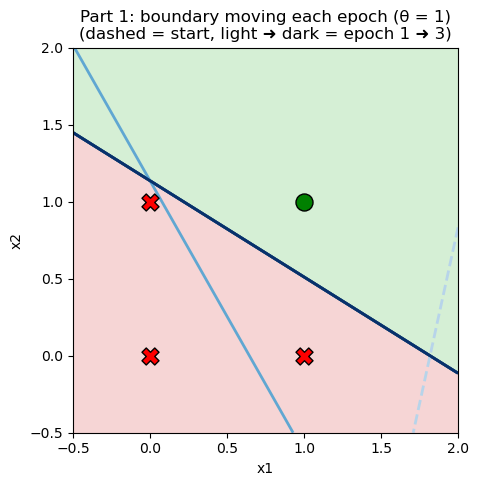

In [6]:
test(X, y, w1)
plot_history(hist1, "Part 1: boundary moving each epoch (θ = 1)")

---
## Part 2: threshold as $w_0$

Add $x_0 = -1$: $\;w_0 \cdot (-1) + w_1 x_1 + w_2 x_2 \ge 0 \iff w_1 x_1 + w_2 x_2 \ge w_0$, so $w_0$ is the threshold and `step` compares with 0.

In [7]:
THETA = 0.0                                   # threshold now lives in w0
X0 = np.hstack([-np.ones((len(X), 1), dtype=int), X])
print(X0)

w = rng.uniform(-1, 1, size=3).round(2)       # random start: w0 (threshold), w1, w2
print("\nStart w =", w)
test(X0, y, w)

[[-1  0  0]
 [-1  0  1]
 [-1  1  0]
 [-1  1  1]]

Start w = [ 0.72  0.39 -0.81]
x=[-1  0  0] | s = -0.72 ≥ 0? -> 0 | target 0 ✓
x=[-1  0  1] | s = -1.53 ≥ 0? -> 0 | target 0 ✓
x=[-1  1  0] | s = -0.33 ≥ 0? -> 0 | target 0 ✓
x=[-1  1  1] | s = -1.14 ≥ 0? -> 0 | target 1 ✗


In [8]:
w2, _, hist2 = train(X0, y, w, lr=1, epochs=30)

--- Epoch 1 ---
x=[-1  0  0] | s = -1×0.72 + 0×0.39 + 0×-0.81 = -0.72 ≥ 0? -> 0 | error = 0-0 =  0 | w = [ 0.72  0.39 -0.81]
x=[-1  0  1] | s = -1×0.72 + 0×0.39 + 1×-0.81 = -1.53 ≥ 0? -> 0 | error = 0-0 =  0 | w = [ 0.72  0.39 -0.81]
x=[-1  1  0] | s = -1×0.72 + 1×0.39 + 0×-0.81 = -0.33 ≥ 0? -> 0 | error = 0-0 =  0 | w = [ 0.72  0.39 -0.81]
x=[-1  1  1] | s = -1×0.72 + 1×0.39 + 1×-0.81 = -1.14 ≥ 0? -> 0 | error = 1-0 =  1 | w = [-0.28  1.39  0.19]
mistakes: 1

--- Epoch 2 ---
x=[-1  0  0] | s = -1×-0.28 + 0×1.39 + 0×0.19 = 0.28 ≥ 0? -> 1 | error = 0-1 = -1 | w = [0.72 1.39 0.19]
x=[-1  0  1] | s = -1×0.72 + 0×1.39 + 1×0.19 = -0.53 ≥ 0? -> 0 | error = 0-0 =  0 | w = [0.72 1.39 0.19]
x=[-1  1  0] | s = -1×0.72 + 1×1.39 + 0×0.19 = 0.67 ≥ 0? -> 1 | error = 0-1 = -1 | w = [1.72 0.39 0.19]
x=[-1  1  1] | s = -1×1.72 + 1×0.39 + 1×0.19 = -1.14 ≥ 0? -> 0 | error = 1-0 =  1 | w = [0.72 1.39 1.19]
mistakes: 3

--- Epoch 3 ---
x=[-1  0  0] | s = -1×0.72 + 0×1.39 + 0×1.19 = -0.72 ≥ 0? -> 0 | error 

x=[-1  0  0] | s = -2.72 ≥ 0? -> 0 | target 0 ✓
x=[-1  0  1] | s = -1.53 ≥ 0? -> 0 | target 0 ✓
x=[-1  1  0] | s = -0.33 ≥ 0? -> 0 | target 0 ✓
x=[-1  1  1] | s = 0.86 ≥ 0? -> 1 | target 1 ✓

Learned threshold w0 = 2.72


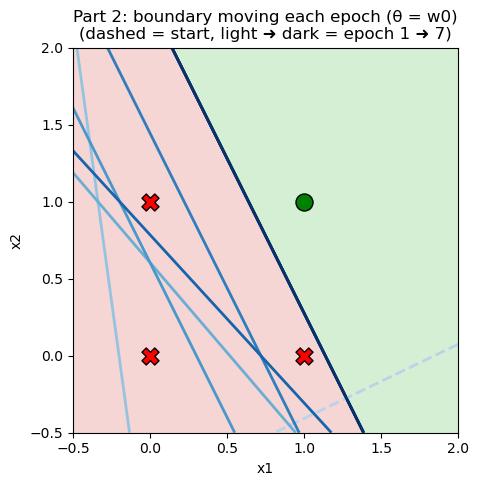

In [9]:
test(X0, y, w2)
print(f"\nLearned threshold w0 = {w2[0]:g}")
plot_history(hist2, "Part 2: boundary moving each epoch (θ = w0)")

---
## Experiment 1: learning rate (Part 2, 50 random starts each)

In [10]:
starts = [rng.uniform(-1, 1, size=3).round(2) for _ in range(50)]

print(f"{'lr':>8} | {'learned':>7} | {'avg epochs':>10} | final w from Part 2 start {w}")
print("-" * 78)
for lr in [0.0001, 0.001, 0.01, 0.1, 1, 10, 100]:
    epochs_needed = [train_quiet(X0, y, s0, lr, epochs=100)[1] for s0 in starts]
    w_final = train_quiet(X0, y, w, lr, epochs=100)[0]
    done = [e for e in epochs_needed if e is not None]
    avg = f"{np.mean(done):.1f}" if done else "-"
    print(f"{lr:>8} | {len(done):>3}/50  | {avg:>10} | {w_final}")

      lr | learned | avg epochs | final w from Part 2 start [ 0.72  0.39 -0.81]
------------------------------------------------------------------------------
  0.0001 |   2/50  |        1.0 | [ 0.71  0.4  -0.8 ]
   0.001 |   3/50  |        9.7 | [ 0.62  0.49 -0.71]
    0.01 |  44/50  |       54.2 | [0.56 0.55 0.01]
     0.1 |  50/50  |        9.7 | [0.62 0.49 0.19]
       1 |  50/50  |        5.9 | [2.72 2.39 1.19]
      10 |  50/50  |        5.7 | [20.72 20.39  9.19]
     100 |  50/50  |        5.7 | [200.72 200.39  99.19]


### Graph: same start, different η

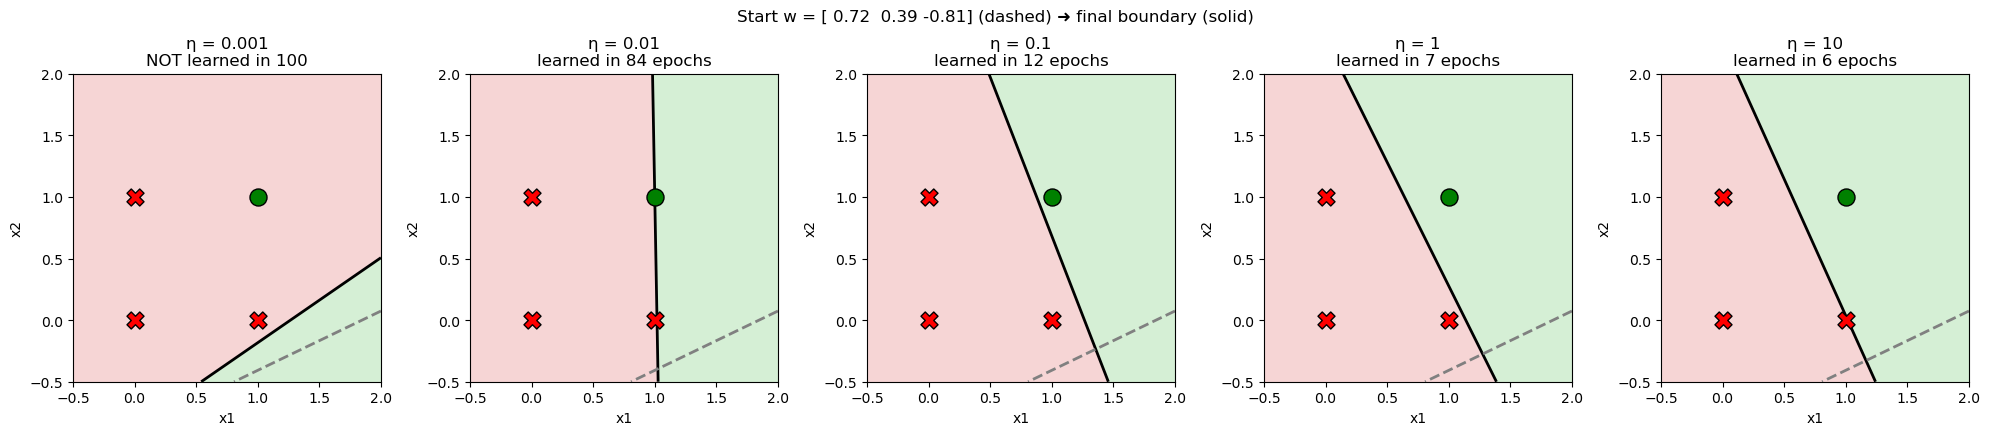

In [11]:
lrs = [0.001, 0.01, 0.1, 1, 10]
fig, axes = plt.subplots(1, len(lrs), figsize=(4 * len(lrs), 4.3))
for ax, lr in zip(axes, lrs):
    w_final, n, hist = train_quiet(X0, y, w, lr, epochs=100)
    draw_line(ax, w_final, shade=True)
    draw_line(ax, w, color="gray", style="--")
    result = f"learned in {n} epochs" if n else "NOT learned in 100"
    draw_points(ax, f"η = {lr}\n{result}")
fig.suptitle(f"Start w = {w} (dashed) ➜ final boundary (solid)")
plt.tight_layout()
plt.show()

### Graph: same η, different random starts

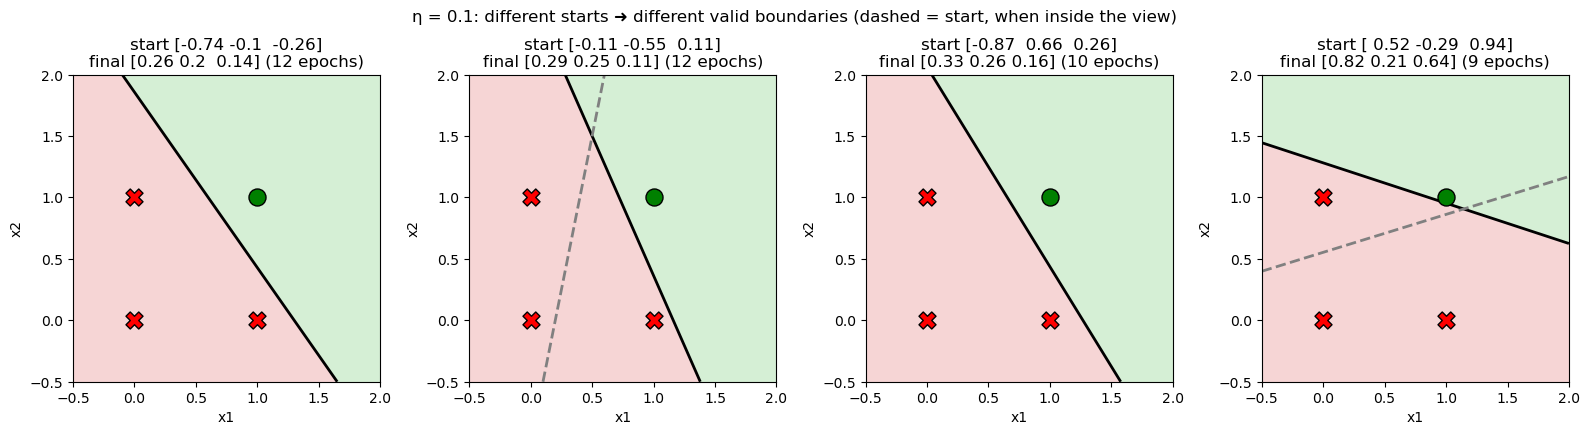

In [12]:
needs_training = [s0 for s0 in starts if train_quiet(X0, y, s0, 0.1, epochs=100)[1] > 1][:4]

fig, axes = plt.subplots(1, 4, figsize=(16, 4.3))
for ax, w_start in zip(axes, needs_training):
    w_final, n, hist = train_quiet(X0, y, w_start, 0.1, epochs=100)
    draw_line(ax, w_final, shade=True)
    draw_line(ax, w_start, color="gray", style="--")
    draw_points(ax, f"start {w_start}\nfinal {w_final} ({n} epochs)")
fig.suptitle("η = 0.1: different starts ➜ different valid boundaries (dashed = start, when inside the view)")
plt.tight_layout()
plt.show()

### Graph: how η changes the path (boundary after every epoch)

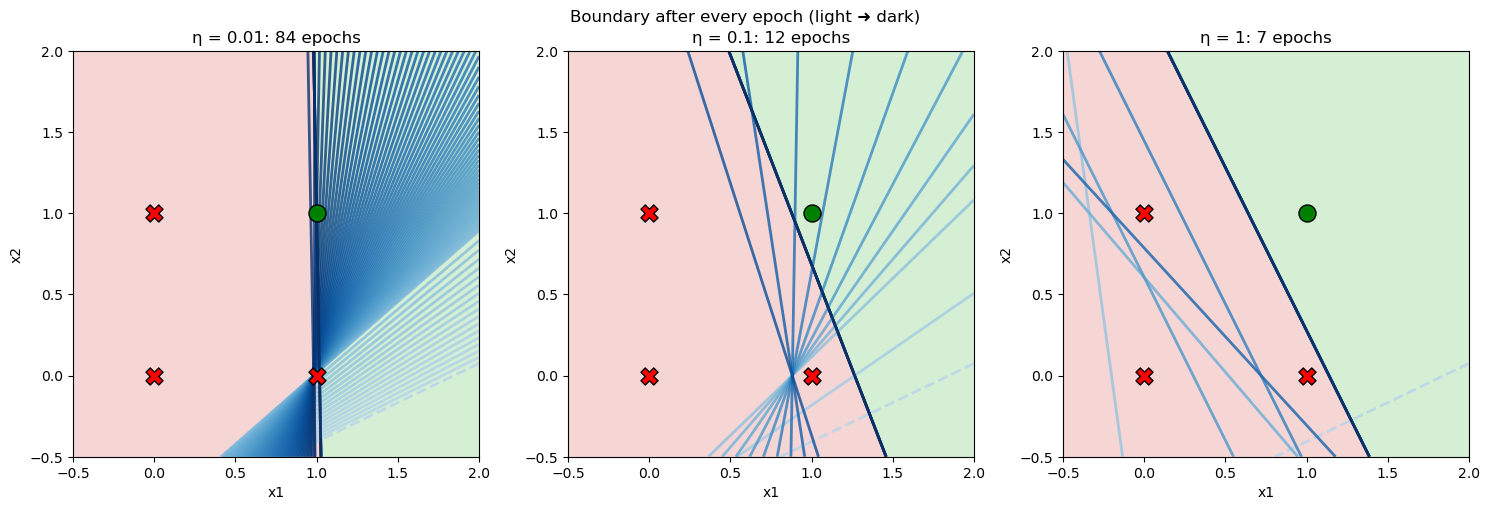

In [13]:
lrs = [0.01, 0.1, 1]
fig, axes = plt.subplots(1, len(lrs), figsize=(15, 5))
for ax, lr in zip(axes, lrs):
    w_final, n, hist = train_quiet(X0, y, w, lr, epochs=100)
    draw_line(ax, w_final, shade=True)
    colors = plt.cm.Blues(np.linspace(0.3, 1, len(hist)))
    for i, w_e in enumerate(hist):
        draw_line(ax, w_e, color=colors[i], style="--" if i == 0 else "-", alpha=0.8)
    draw_points(ax, f"η = {lr}: {len(hist) - 1} epochs")
fig.suptitle("Boundary after every epoch (light ➜ dark)")
plt.tight_layout()
plt.show()